# 05 - Підсумок: від 2 діб до 588. Енергетика вузла крізь усі дослідження

## Що тут відбувається

Це заключний ноутбук серії. У 01–04 ми відповідали на окремі питання: шум і зсув сенсора (01), швидкість реальних змін ґрунту (02), оптимальне вікно відліків (03), тривалість прогріву (04). Тут усі відповіді збираються в одну модель: **скільки діб живе вузол від батареї на кожному кроці оптимізації - і який внесок кожного дослідження.**

## Для чого

Вузол живиться від однієї банки 18650 (~3000 мА·год реально доступних). Кожне рішення прошивки - скільки відліків робити, скільки пакетів слати, скільки грітись, як спати - конвертується в доби автономності. Ця таблиця показує ціну кожного рішення в добах і доводить, що оптимізації не погіршили якість даних.

Струми заміряні мультиметром : неспання 37 мА, передача 100 мА (0.86 с/пакет), сон 0.01 мА після правки (до неї - 0.94 мА).

In [1]:
I_AWAKE = 37       # мА, неспання 80 МГц
I_TX = 100         # мА, передача
T_TX = 0.86        # с, один пакет
CAPACITY = 3000    # мА·год

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    {"name": "v1: 7 відліків × 7 пакетів",           "t_awake": 19.5, "n_packets": 7, "i_sleep": 0.96},
    {"name": "v1: вікно [2..4] 3 × 3",               "t_awake": 13.1, "n_packets": 3, "i_sleep": 0.96},
    {"name": "v1: вікно [1..3] 3 × 3",               "t_awake": 10.0, "n_packets": 3, "i_sleep": 0.96},
    {"name": "v1: 3 × 3 Оптимізований deep sleep",   "t_awake": 10.0,  "n_packets": 3, "i_sleep": 0.01},
    {"name": "v2: 3 × 3 пакети, прогрів 3с",         "t_awake": 4.6,  "n_packets": 3, "i_sleep": 0.01},
    {"name": "v2: 3 × 1, прогрів 3с",                "t_awake": 4.6,  "n_packets": 1, "i_sleep": 0.01},  # крок 2 — v2: відліки щільно (50мс) і все в 1 пакет
    {"name": "v2.1: прогрів ~1с (в роботі)",         "t_awake": 2.6,  "n_packets": 1, "i_sleep": 0.01},  # крок 3 — ноутбук 04: у повітрі зсув<1.38 за ~3с, у ґрунті ~втричі швидше
    
]

def cycle_energy(t_awake, n_packets, t_cycle, i_sleep):
    t_tx = n_packets * T_TX
    t_sleep = t_cycle - t_awake - t_tx
    e_awake = t_awake * I_AWAKE
    e_tx = t_tx * I_TX
    e_sleep = t_sleep * i_sleep
    e_total = e_awake + e_tx + e_sleep
    return {
        "i_avg": e_total / t_cycle,
        "pct_awake": e_awake / e_total * 100,
        "pct_tx": e_tx / e_total * 100,
        "pct_sleep": e_sleep / e_total * 100,
    }

rows = [{
    "сценарій": "v0: перший прогін (без сну)",
    "мА (5хв)": None,  "діб (5хв)": None,
    "мА (15хв)": 69,   "діб (15хв)": round(CAPACITY / 69 / 24),
    "% вікно": 100, "% передача": None, "% сон": 0,
}]

for s in scenarios:
    r5 = cycle_energy(s["t_awake"], s["n_packets"], 300, s["i_sleep"])
    r15 = cycle_energy(s["t_awake"], s["n_packets"], 900, s["i_sleep"])
    rows.append({
        "сценарій": s["name"],
        "мА (5хв)": round(r5["i_avg"], 2),   "діб (5хв)": round(CAPACITY / r5["i_avg"] / 24),
        "мА (15хв)": round(r15["i_avg"], 2), "діб (15хв)": round(CAPACITY / r15["i_avg"] / 24),
        "% вікно": round(r15["pct_awake"]),
        "% передача": round(r15["pct_tx"]),
        "% сон": round(r15["pct_sleep"]),
    })

summary = pd.DataFrame(rows)

summary["діб (5хв)"] = summary["діб (5хв)"].astype("Int64")
summary["приріст, %"] = (summary["діб (15хв)"].pct_change() * 100).round().astype("Int64")

summary["×"] = (summary["діб (15хв)"] / summary["діб (15хв)"].shift(1)).round(2)


print(f"1 с неспання      = {I_AWAKE} мА·с")
print(f"1 пакет           = {T_TX * I_TX:.0f} мА·с  (≈ {T_TX * I_TX / I_AWAKE:.1f} с неспання)")
print(f"1 год сну (0.01)  = {3600 * 0.01:.0f} мА·с")
print(f"курс: 1 с неспання = {I_AWAKE / 0.01:.0f} с сну")
summary

1 с неспання      = 37 мА·с
1 пакет           = 86 мА·с  (≈ 2.3 с неспання)
1 год сну (0.01)  = 36 мА·с
курс: 1 с неспання = 3700 с сну


,сценарій,мА (5хв),діб (5хв),мА (15хв),діб (15хв),% вікно,% передача,% сон,"приріст, %",×
0,v0: перший прогін (без сну),NaN,<NA>,69.00,2,100,NaN,0,<NA>,NaN
1,v1: 7 відліків × 7 пакетів,5.29,24,2.40,52,33,28.0,39,2500,26.00
2,v1: вікно [2..4] 3 × 3,3.39,37,1.77,71,30,16.0,53,37,1.37
3,v1: вікно [1..3] 3 × 3,3.01,41,1.64,76,25,17.0,58,7,1.07
4,v1: 3 × 3 Оптимізований deep sleep,2.10,59,0.71,177,58,41.0,1,133,2.33
5,"v2: 3 × 3 пакети, прогрів 3с",1.44,87,0.49,257,39,59.0,2,45,1.45
6,"v2: 3 × 1, прогрів 3с",0.86,145,0.29,424,64,32.0,3,65,1.65
7,v2.1: прогрів ~1с (в роботі),0.62,203,0.21,588,50,45.0,5,39,1.39


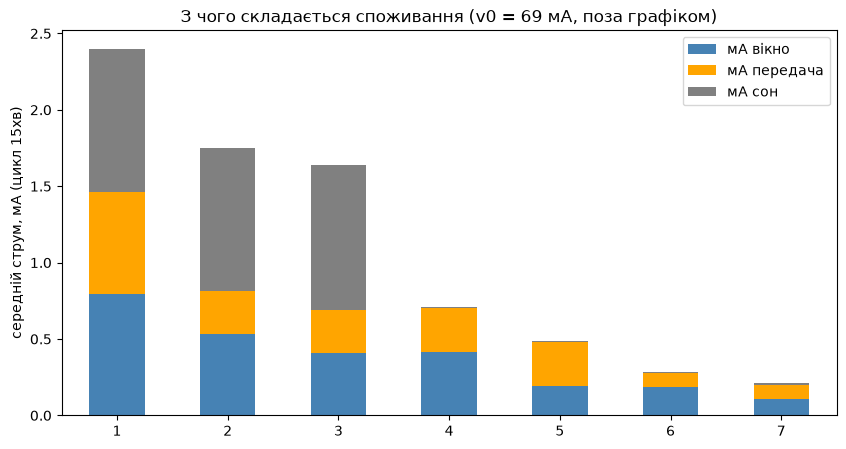

In [3]:
# --- мА кожної фази (15хв цикл) ---
summary["мА вікно"] = summary["мА (15хв)"] * summary["% вікно"] / 100
summary["мА передача"] = summary["мА (15хв)"] * summary["% передача"] / 100
summary["мА сон"] = summary["мА (15хв)"] * summary["% сон"] / 100

# --- stacked bar: склад споживання в абсолютних мА, без v0 ---
plot_df = summary.iloc[1:][["мА вікно", "мА передача", "мА сон"]]

plot_df.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=["steelblue", "orange", "gray"],
)
plt.ylabel("середній струм, мА (цикл 15хв)")
plt.title("З чого складається споживання (v0 = 69 мА, поза графіком)")
plt.xticks(rotation=0)
plt.legend(title="")
plt.show()

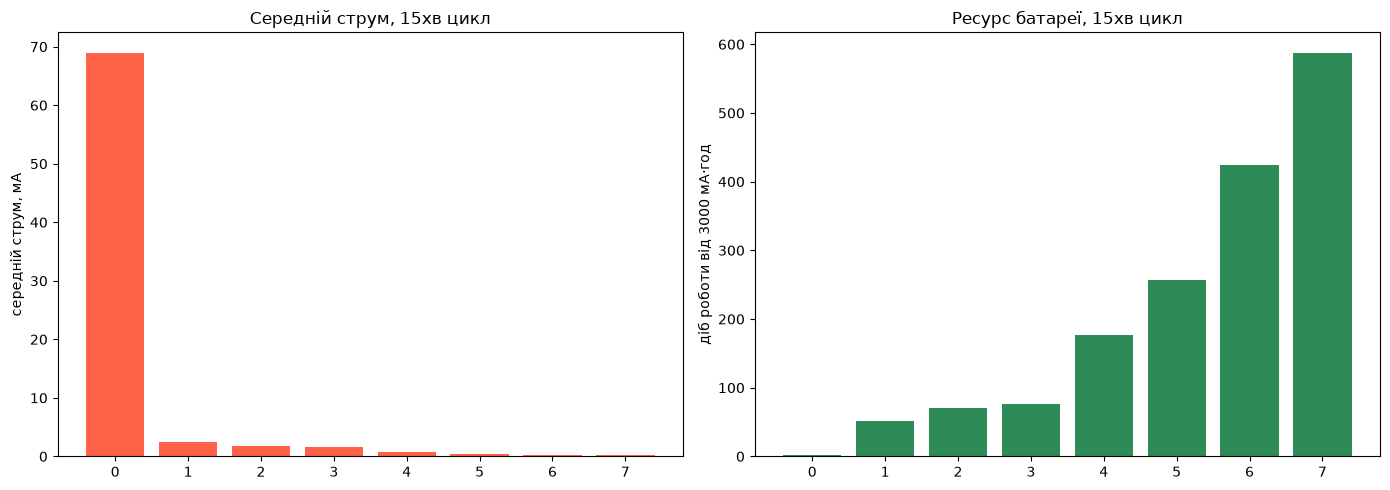

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar( summary.index.astype(str), summary["мА (15хв)"], color="tomato")
ax1.set_ylabel("середній струм, мА")
ax1.set_title("Середній струм, 15хв цикл")

ax2.bar( summary.index.astype(str), summary["діб (15хв)"], color="seagreen")
ax2.set_ylabel("діб роботи від 3000 мА·год")
ax2.set_title("Ресурс батареї, 15хв цикл")

plt.tight_layout()
plt.show()

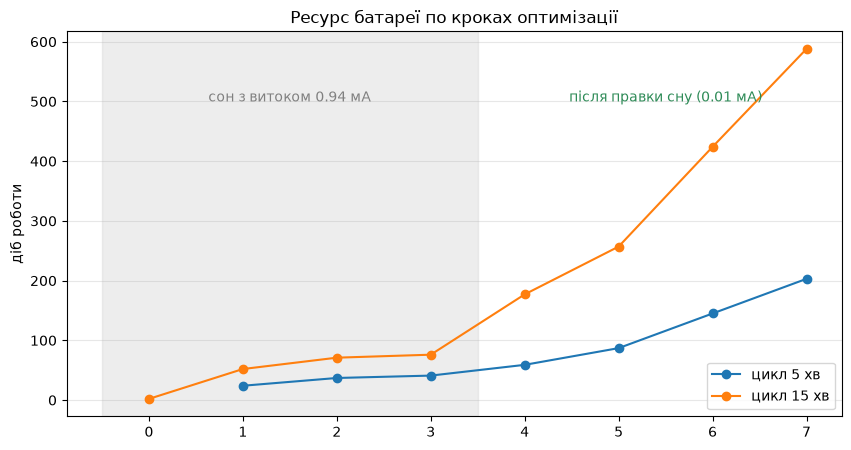

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(summary.index.astype(str), summary["діб (5хв)"], marker="o", label="цикл 5 хв")
plt.plot(summary.index.astype(str), summary["діб (15хв)"], marker="o", label="цикл 15 хв")
plt.ylabel("діб роботи")

plt.axvspan(-0.5, 3.5, color="lightgray", alpha=0.4)
plt.text(1.5, 500, "сон з витоком 0.94 мА", ha="center", color="gray")
plt.text(5.5, 500, "після правки сну (0.01 мА)", ha="center", color="seagreen")
plt.title("Ресурс батареї по кроках оптимізації")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## Висновок

Шлях від v0 до v2.1 - **з 2 діб до 588 (цикл 15 хв), ~×300.** Кожен крок
спирався на заміряне число, не на здогадку:

| крок | що довело | виграш |
|---|---|---|
| v0 → v1: deep sleep + цикл | очевидне: 69 мА без сну - 2 доби | ×26 |
| 7 → 3 відліки, вікно коротше | поз.0 бита (−22 у 442/442 бурстах, ноутбук 01); 3 відліки не гірші за 7 (p90 ≈ 3, ноутбук 03) | вікно 19.5с → 10с |
| правка сну 0.94 → 0.01 мА | виток у пінах прошивки (струм-сну.md); сон їв до 58% бюджету | курс неспання/сон виріс з 47 до 3700 |
| 3 пакети → 1 пакет | для даних байдуже, для батареї — мінус 2×86 мА·с/цикл | % передачі: головна стаття → друга |
| щільні відліки (50 мс) | ґрунт за секунди не міняється (за 15 хв - лише 1.38, ноутбук 02) | вікно 10с → 4.6с |
| прогрів 3с → ~1с (очікується) | у повітрі зсув < 1.38 за ~3с; у ґрунті ~втричі швидше (ноутбук 04) | вікно 4.6с → 2.6с |

У v2.1 бюджет майже вичерпаний: вікно + передача = 95% енергії, і це вже фізика (одне вимірювання + один пакет). Далі виграє лише інтервал (15 → 30 хв) або джерело: більша банка, дві паралельно, чи сонячна панель - ресурс масштабується лінійно з мА·год.

## Якість даних

Економія не коштувала точності — навпаки:

- v1 клала в базу всі 7 позицій, включно з битою поз.0 → зсув проти істини **−3.64**. v2 викидає поз.0 → зсув **−1.57** (етап-4).
- Вбудований тест при розгортанні v2: рівень soil_raw має піднятись на **+2.08**. Збіжиться - весь ланцюг міркувань підтверджено полем.
- Відкрите: чи незалежні щільні відліки через 50 мс (v2 шле soil_min/max саме для перевірки); втрата єдиного пакета v2 = втрата циклу - ціна одна 15-хв дірка (менша за шум), реальний % втрат заміряє етап 4.